# EDA on 2‑month traffic dataset

Goal: get a first feel for the dataset, its columns, and basic patterns in traffic.

1. Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data/raw/TrafficTwoMonth.csv')
df.head()
df.info()
print(df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].describe())
print(df['Traffic Situation'].unique())
print(df.groupby('Traffic Situation')['CarCount'].mean().sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB
          CarCount    BikeCount     BusCount   TruckCount
count  5952.000000  5952.000000  5952.000000  5952.000000
mean     65.440692    12.161458    12.912970    18.646337
std      44.749335    11.537944    12.497736    10.973139
min       5.000000     0.000000     0.000000     0.000000
25%      18.750000     3.000000    

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB


In [3]:
counts = df['Traffic Situation'].value_counts()
print("the distribution of traffic types:")
print(counts)

the distribution of traffic types:
Traffic Situation
normal    3610
heavy     1137
low        834
high       371
Name: count, dtype: int64


2. Visualization of dataset

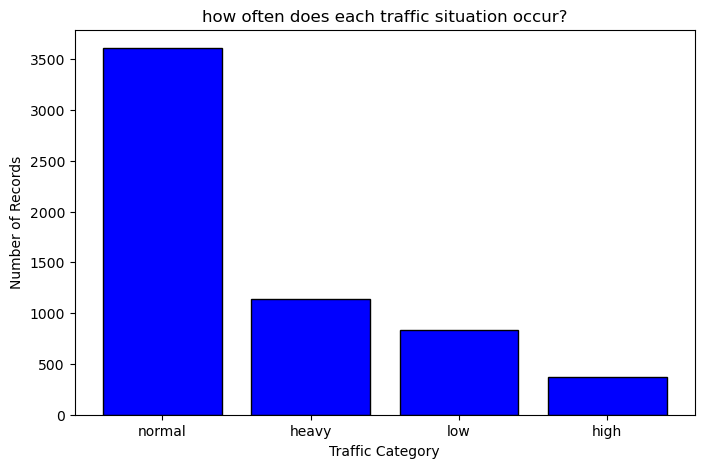

In [4]:
labels = counts.index
values = counts.values
plt.figure(figsize=(8, 5))
plt.bar(labels, values, color='blue', edgecolor='black')
plt.xlabel('Traffic Category')
plt.ylabel('Number of Records')
plt.title('how often does each traffic situation occur?')
plt.show()

In [5]:
df['Time'] = pd.to_datetime(df['Time'])
df['hour'] = df['Time'].dt.hour

C:\Users\nitaa\AppData\Local\Temp\ipykernel_29344\1211914487.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


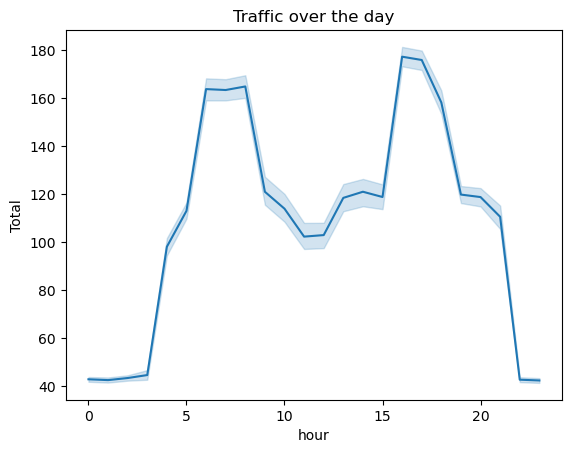

In [6]:
sns.lineplot(data=df, x='hour', y='Total')
plt.title("Traffic over the day")
plt.show()

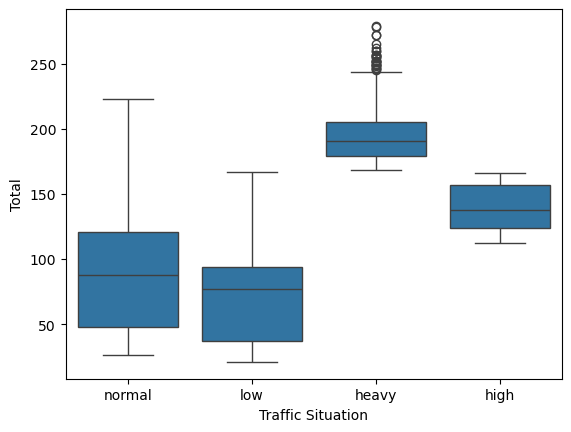

In [7]:
sns.boxplot(data=df, x='Traffic Situation', y='Total')
plt.show()

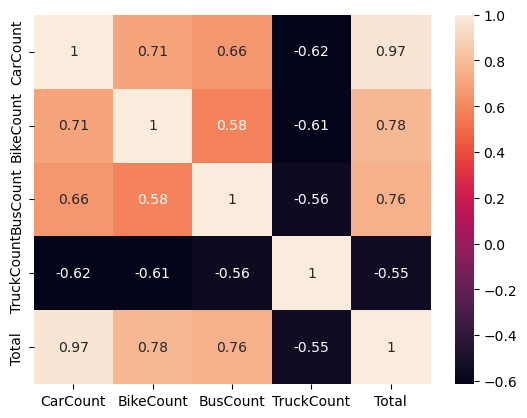

In [8]:
sns.heatmap(df[['CarCount','BikeCount','BusCount','TruckCount','Total']].corr(), annot=True)
plt.show()